# Problem Understanding

## Task

In this project, the goal is to predict human emotions from textual data. A single piece of text can express multiple emotions at the same time; therefore, this problem is formulated as a **multi-label emotion classification task** rather than a single-label classification problem.

- Input: Text data (e.g., messages, social media posts, reviews)
- Output: A set of emotion labels associated with each text

## Motivation and Importance

Understanding human emotions from text is an important application in natural language processing. Accurately identifying emotions can provide valuable insights into user behavior and mental states.

This task has several real-world applications, including:

- Enhancing user experience in messaging applications and social media platforms
- Monitoring emotional trends in online communities
- Supporting mental health initiatives by identifying - users who may be in distress
- Assisting in early detection of harmful or risky behaviors

By enabling systems to automatically recognize emotional patterns in text, we can build tools that respond more intelligently and responsibly to human needs.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
import re
from wordcloud import WordCloud

# Load Data

In [2]:
df_1 = pd.read_csv('../data/raw/goemotions_1.csv') # Loading first csv file
df_2 = pd.read_csv('../data/raw/goemotions_2.csv') # Loading second csv file
df_3 = pd.read_csv('../data/raw/goemotions_3.csv') # Loading third csv file

In [3]:
# Since there are three dataframes containing data Let's concataneted three of them to a single dataframe
df = pd.concat([df_1, df_2, df_3], axis = 0) 

In [4]:
df.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 211225 entries, 0 to 71224
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   text                  211225 non-null  str    
 1   id                    211225 non-null  str    
 2   author                211225 non-null  str    
 3   subreddit             211225 non-null  str    
 4   link_id               211225 non-null  str    
 5   parent_id             211225 non-null  str    
 6   created_utc           211225 non-null  float64
 7   rater_id              211225 non-null  int64  
 8   example_very_unclear  211225 non-null  bool   
 9   admiration            211225 non-null  int64  
 10  amusement             211225 non-null  int64  
 11  anger                 211225 non-null  int64  
 12  annoyance             211225 non-null  int64  
 13  approval              211225 non-null  int64  
 14  caring                211225 non-null  int64  
 15  confusion        

In [6]:
df.describe()

,created_utc,rater_id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
count,2.112250e+05,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,...,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000
mean,1.547659e+09,37.619742,0.081103,0.043768,0.038272,0.064472,0.083418,0.028401,0.034840,0.045885,...,0.038779,0.008569,0.041259,0.006164,0.041591,0.006102,0.011954,0.031994,0.026105,0.261797
std,7.696842e+05,23.070528,0.272994,0.204580,0.191853,0.245592,0.276514,0.166116,0.183374,0.209236,...,0.193067,0.092172,0.198890,0.078269,0.199653,0.077880,0.108679,0.175985,0.159448,0.439614
min,1.546301e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.546993e+09,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.547664e+09,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.548320e+09,57.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.548979e+09,81.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Data Overview

In [7]:
# Number of entries in the dataset
print(f"Number of entries in the dataset: {len(df)}")

Number of entries in the dataset: 211225


In [8]:
# Column names and there data types
print(f"Column names and their data types:\n{df.dtypes}")

Column names and their data types:
text                        str
id                          str
author                      str
subreddit                   str
link_id                     str
parent_id                   str
created_utc             float64
rater_id                  int64
example_very_unclear       bool
admiration                int64
amusement                 int64
anger                     int64
annoyance                 int64
approval                  int64
caring                    int64
confusion                 int64
curiosity                 int64
desire                    int64
disappointment            int64
disapproval               int64
disgust                   int64
embarrassment             int64
excitement                int64
fear                      int64
gratitude                 int64
grief                     int64
joy                       int64
love                      int64
nervousness               int64
optimism                  int64
pride

According to the above info there are numerical and text based data in this dataset

In [9]:
# Missing values in the dataset
print(f"Missing values in the dataset:\n{df.isnull().sum()}")

Missing values in the dataset:
text                    0
id                      0
author                  0
subreddit               0
link_id                 0
parent_id               0
created_utc             0
rater_id                0
example_very_unclear    0
admiration              0
amusement               0
anger                   0
annoyance               0
approval                0
caring                  0
confusion               0
curiosity               0
desire                  0
disappointment          0
disapproval             0
disgust                 0
embarrassment           0
excitement              0
fear                    0
gratitude               0
grief                   0
joy                     0
love                    0
nervousness             0
optimism                0
pride                   0
realization             0
relief                  0
remorse                 0
sadness                 0
surprise                0
neutral                 0
dtype: 

According to this there are no any missing value entries in this dataset. Since, there is no any missing values there is no need to handle missing values.

In [10]:
# Duplicate values in the dataset
print(f"Duplicate values in the dataset: {df.duplicated().sum()}")

Duplicate values in the dataset: 0


Also in this dataset there are no duplicate values. So, there is no need to handle duplicate values in this dataset.

# Target Variable Analysis

Since there is Multiple labels first let's identify label distribution.

In [11]:
emotion_labels = df.columns[9:] # Get the emotion label columns
print(f"Emotion labels: {emotion_labels.tolist()}")
print(f"Length of emotion labels: {len(emotion_labels)}")

Emotion labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Length of emotion labels: 28


### Label Distribution

In [12]:

emotions_count = df[emotion_labels].sum() # Sum the values in each emotion label column
emotions_count = emotions_count.sort_values(ascending=False) # Sort the counts in descending order
print(f"Emotion counts:\n{emotions_count}")

Emotion counts:
neutral           55298
approval          17620
admiration        17131
annoyance         13618
gratitude         11625
disapproval       11424
curiosity          9692
amusement          9245
realization        8785
optimism           8715
disappointment     8469
love               8191
anger              8084
joy                7983
confusion          7359
sadness            6758
caring             5999
excitement         5629
surprise           5514
disgust            5301
desire             3817
fear               3197
remorse            2525
embarrassment      2476
nervousness        1810
pride              1302
relief             1289
grief               673
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_29876\975803699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotions_count.index, y=emotions_count.values, palette='viridis')


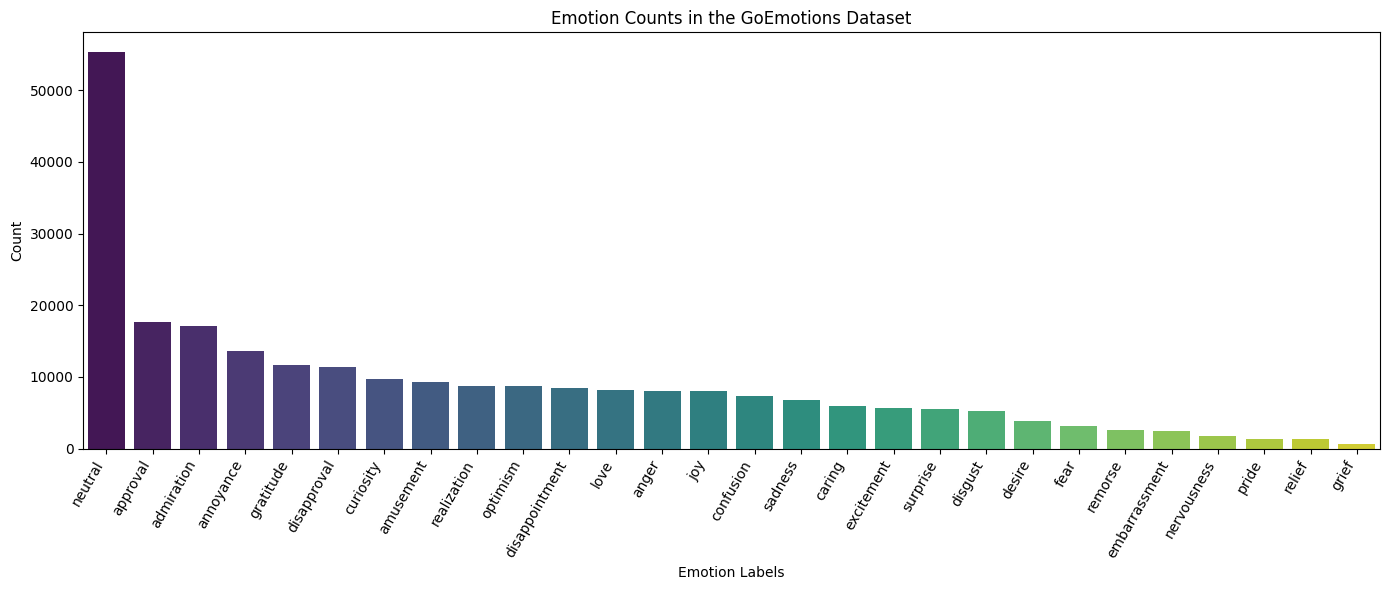

<Figure size 640x480 with 0 Axes>

In [13]:
# Let's display the emotion counts in a bar plot
plt.figure(figsize=(14, 6))
sns.barplot(x=emotions_count.index, y=emotions_count.values, palette='viridis')
plt.title('Emotion Counts in the GoEmotions Dataset')
plt.xlabel('Emotion Labels')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('../experiments/plots/emotion_counts.png')

The dataset contains multiple emotions, with **neutral** being the most frequent followed by **approval** and **admiration**. The counts of some of the less frequent emotions (like grief, relief, and pride) are significantly lower, which indicates a highly imbalanced dataset.

#### Observations
- The neutral class dominates, making up the large portion of the dataset.
- Many emotions like grief, relief and pride have very low counts, which might require class balancing techinque or careful metric selection during modeling.
- There is a long-tail distribution. A few emotions are very frequent while many others are rare.
- Multi-label relationship may exist, as some likely co-occur with neutral or other high-frequency labels.

And also the plot highlights the imbalance and can guide preprocessing and evaluation strategy.

### Multi Label Properties

In [14]:
df['label_count'] = df[emotion_labels].sum(axis=1) # Create a new column to count the number of labels for each entry
print(f"Label count for each entry:\n{df['label_count']}")

Label count for each entry:
0        1
1        0
2        1
3        1
4        1
        ..
71220    1
71221    1
71222    1
71223    1
71224    0
Name: label_count, Length: 211225, dtype: int64


In [15]:
# Identify unique label counts and their frequencies
label_count_freq = df['label_count'].value_counts().sort_index()
print(f"Unique label counts and their frequencies:\n{label_count_freq}")

Unique label counts and their frequencies:
label_count
0       3411
1     171820
2      31187
3       4218
4        399
5        106
6         53
7         20
8          6
9          3
10         1
12         1
Name: count, dtype: int64


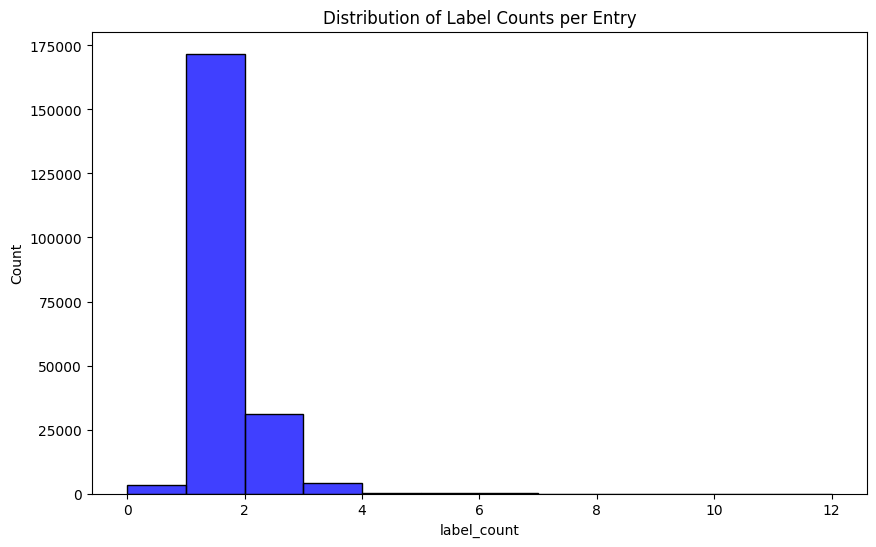

In [16]:
# Histogram of label counts
plt.figure(figsize=(10, 6))
sns.histplot(df['label_count'], bins=range(0, df['label_count'].max() + 1), kde=False, color='blue')
plt.title('Distribution of Label Counts per Entry')
plt.savefig('../experiments/plots/label_count_distribution.png')
plt.show()

The dataset contains multi label samples, meaning simple text can have multiple emotions.

#### Observations
- The majority of texts have only one emotion.
- Multi-label samples are relatively rare, but there cases with up to 12 emotions, indicating some texts are very emotionally rich or amiguous.
- This long-tail distribution will impact model design, as models need to handle both single and multi label casees effectively.
- Evaluation metrics should consider multi-label scenraios

# Text Data Analysis

### Text Length

First let's analyse text length first

In [17]:
df['text_length'] = df['text'].apply(len) # Create a new column to calculate the length of text for each entry
d = df['text_length'] # Get the text length column

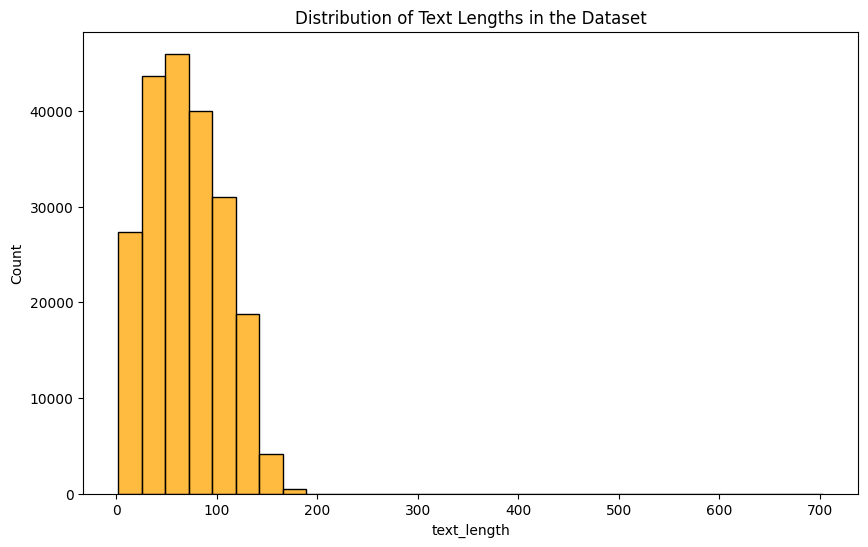

In [18]:
# histogram of text length
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=30, kde=False, color='orange')
plt.title('Distribution of Text Lengths in the Dataset')
plt.savefig('../experiments/plots/text_length_distribution.png')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_29876\930496750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='text_length', data=df, palette='Set2')


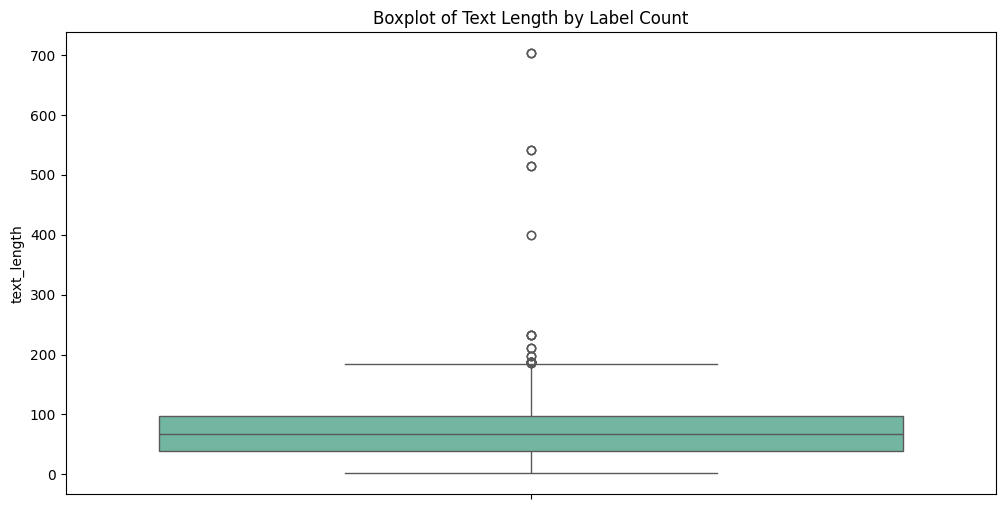

In [19]:
# Boxplot of text length by label count
plt.figure(figsize=(12, 6))
sns.boxplot(y='text_length', data=df, palette='Set2')
plt.title('Boxplot of Text Length by Label Count')
plt.savefig('../experiments/plots/text_length_boxplot.png')

According to the analyze, the distribution of lengths we got these observations.

#### Obesrvations

- The majority of texts are short, with lengths below 100 words.
- There are some longer texts that stand out as outliers, with lengths reaching 400, 500, or even 700 words.
- The box plot confirms that most texts condensed below 100 words, while a few long samples create a long-tail distribution.

#### Implications
- Most models will need to handle short texts efficiently.
- Extremely long texts may require truncation or special preprocessing to avoid skewing the learning process.
- The long-tail nature of text length may also affect padding in vectorization or sequence-based models

Next let's analyse word count of each texts.

In [20]:
df['word_count'] = df['text'].apply(lambda x: len(x.split())) # Create a new column to calculate the word count for each entry
print(f"Word count for each entry:\n{df['word_count']}")

Word count for each entry:
0         3
1        21
2        10
3         4
4        10
         ..
71220     3
71221    16
71222     3
71223    25
71224     8
Name: word_count, Length: 211225, dtype: int64


In [21]:
# Count of each word count
word_count_freq = df['word_count'].value_counts().sort_values(ascending=False)
print(f"Unique word counts and their frequencies:\n{word_count_freq}")

Unique word counts and their frequencies:
word_count
11    10588
14    10349
8     10208
9     10182
10    10152
12    10111
13    10080
7      9866
6      9819
5      9797
15     9788
4      9677
3      9653
16     9251
17     8700
18     8481
19     7849
20     7392
21     6804
22     6299
23     5863
24     5548
25     4131
2      4071
26     2942
27     1869
28      751
1       654
29      263
30       66
31       11
33        5
32        5
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_29876\879197794.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


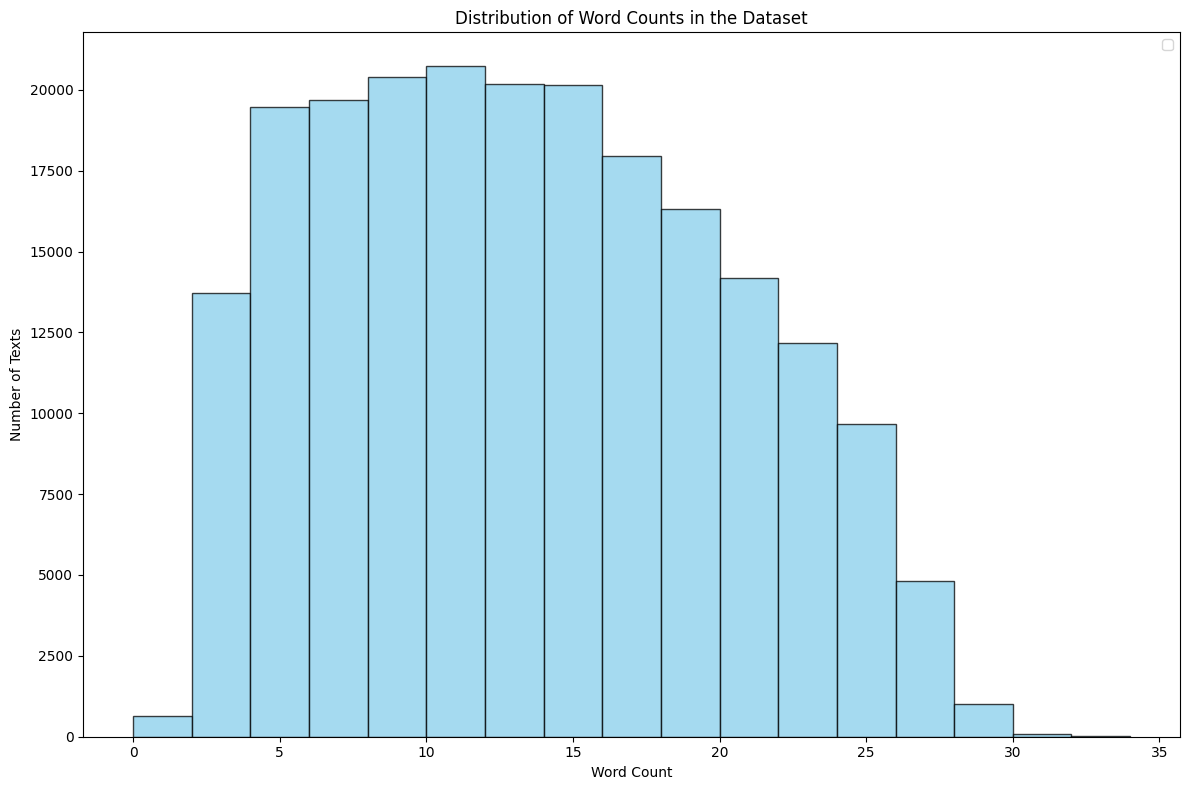

In [22]:
# Histogram of word counts with the most frequent range highlighted
plt.figure(figsize=(12, 8))

bins = range(0, int(df['word_count'].max()) + 2, 2)
plt.hist(df['word_count'], bins=bins, color='skyblue', edgecolor='black', alpha=0.75)


plt.title('Distribution of Word Counts in the Dataset')
plt.xlabel('Word Count')
plt.ylabel('Number of Texts')
plt.legend()
plt.tight_layout()
plt.savefig('../experiments/plots/word_count_distribution.png')
plt.show()

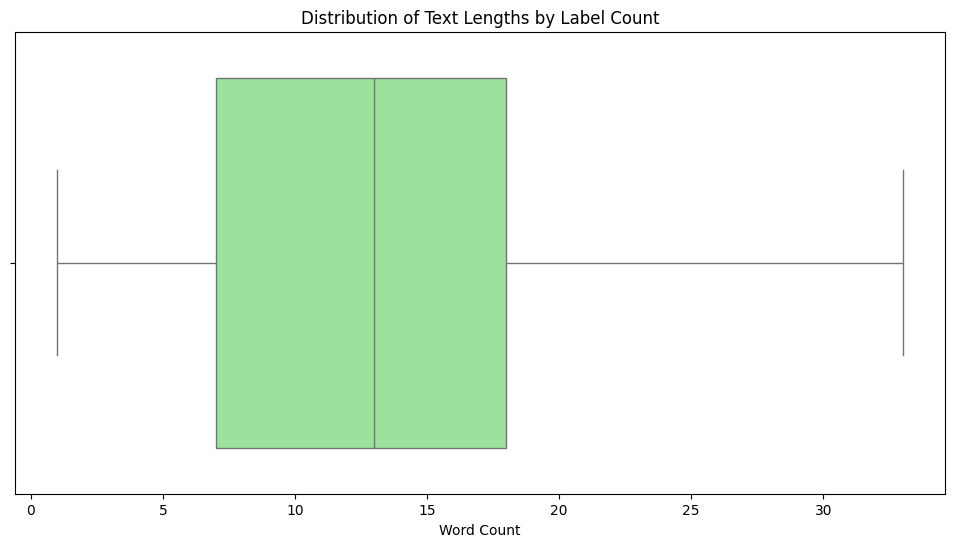

In [23]:
# Box plot of text length by label count
plt.figure(figsize=(12, 6))
sns.boxplot(x = df['word_count'], color='lightgreen')
plt.title('Distribution of Text Lengths by Label Count')
plt.xlabel('Word Count')
plt.savefig('../experiments/plots/word_count_boxplot.png')
plt.show()

#### Observations
- Most texts have 10-12 unique words, which is the peak of the distribution.
- According to the box plot, the majority of texts are condensed between 7 and 18 words, confirming that most samples are relatively sort and use a limited vocabulary.
- A fex texts have very high numbers of unique words (up to 32-33), representing long or complex texts, forming long-tail distribution.

#### Implications for Modeling
- Most texts are concise, so models must efficiently handle short inputs.
- Outliers texts with many unique words may require truncation or special preprocessing to avoid skewing feature vectors.
- The limited number of unique words per text impacts feature sparcity in vectorization methods like Bag-of-Words or TF-IDF.

### Common Words
Next let's identify common words in these texts.

In [24]:
# Make sure NLTK stopwords are downloaded
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
all_text = ' '.join(df['text'].astype(str)) # Combine all text entries into a single string

all_text = all_text.lower() # Convert to lowercase
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text) # Remove non-alphabetic characters

words = all_text.split() # Split the text into individual words

# Remove stopwords
stop_words = set(stopwords.words('english'))
words = [w for w in words if w not in stop_words]

word_count = Counter(words) # Count the frequency of each word

common_words = word_count.most_common(20) # Get the 20 most common words
print(f"Most common words:\n{common_words}")


Most common words:
[('name', 38211), ('like', 16347), ('im', 15110), ('dont', 11971), ('get', 9166), ('thats', 9032), ('one', 8854), ('would', 8572), ('people', 8547), ('love', 8380), ('good', 8216), ('think', 7208), ('really', 7123), ('know', 7063), ('youre', 5996), ('time', 5780), ('see', 5617), ('lol', 5311), ('thanks', 5226), ('even', 4869)]


### Word Colud Visualization

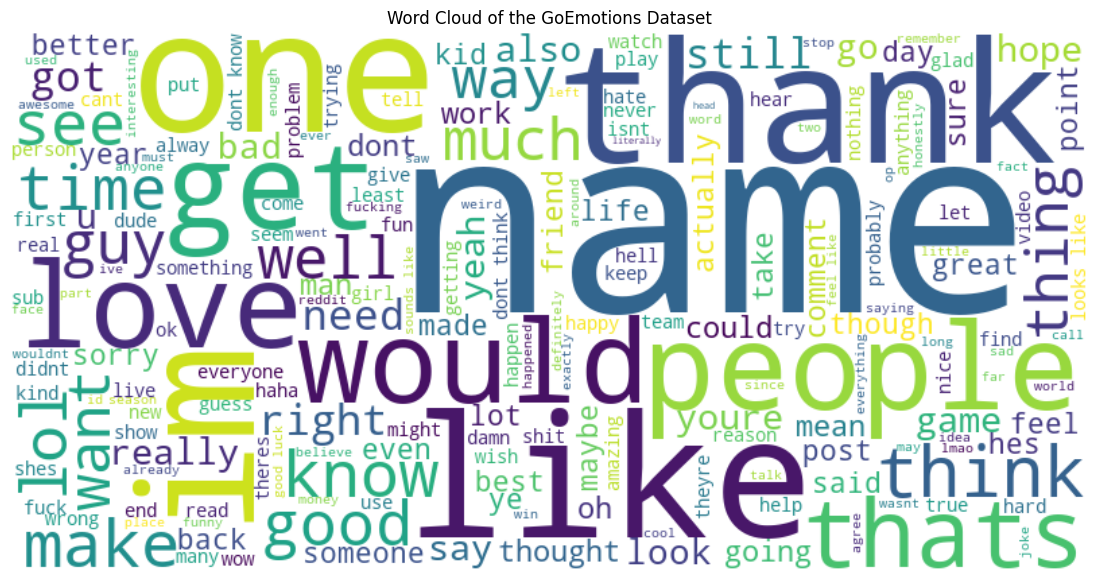

In [26]:
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(all_text) # Generate a word cloud

# plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of the GoEmotions Dataset')
plt.savefig('../experiments/plots/word_cloud.png')
plt.show()

#### Observations
- Many common words are general conversational words like *like*, *im*, *dont*, *thats*, *one*, *would*.
- Some words indicate emotions or interactions, such as love, good, lol, thanks.
- This highlights that the dataset contains informal, conversational text with many short, casual phrases.
- These frequent words may dominate feature vectors, so careful prepricessing or weighting may help improve modeling

# Correlation Between Labels

In [27]:
df[emotion_labels].corr()

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
admiration,1.000000,-0.031093,-0.053570,-0.066833,-0.003953,-0.024798,-0.041124,-0.038462,-0.011401,-0.044983,...,0.005092,-0.019153,-0.009052,0.028894,-0.028533,-0.012145,-0.025178,-0.041496,-0.024059,-0.176921
amusement,-0.031093,1.000000,-0.034839,-0.041558,-0.029560,-0.028777,-0.023232,-0.022696,-0.018774,-0.032991,...,-0.014564,-0.016124,-0.017621,-0.011527,-0.016866,-0.009930,-0.016506,-0.027061,-0.018046,-0.127407
anger,-0.053570,-0.034839,1.000000,0.087398,-0.050632,-0.026679,-0.027001,-0.031481,-0.020949,-0.005676,...,-0.029076,-0.011317,-0.033939,-0.014449,-0.027590,-0.012780,-0.014222,-0.017477,-0.025077,-0.118798
annoyance,-0.066833,-0.041558,0.087398,1.000000,-0.061976,-0.033510,-0.031900,-0.032509,-0.026640,0.020438,...,-0.044041,-0.013949,-0.038175,-0.016487,-0.030065,-0.015372,-0.018765,-0.027352,-0.031857,-0.156333
approval,-0.003953,-0.029560,-0.050632,-0.061976,1.000000,-0.006022,-0.039390,-0.038827,-0.016247,-0.043678,...,-0.031773,-0.022288,0.001809,-0.008227,0.008247,-0.005832,-0.021682,-0.040447,-0.033499,-0.179655
caring,-0.024798,-0.028777,-0.026679,-0.033510,-0.006022,1.000000,-0.026733,-0.022783,0.001625,-0.026371,...,0.007730,-0.009402,0.022424,-0.001449,-0.010492,0.001973,-0.004645,-0.004200,-0.022272,-0.101816
confusion,-0.041124,-0.023232,-0.027001,-0.031900,-0.039390,-0.026733,1.000000,0.051372,-0.019572,-0.025670,...,-0.030271,-0.008140,-0.028640,-0.012324,-0.013069,-0.012235,-0.009970,-0.025885,-0.008437,-0.113144
curiosity,-0.038462,-0.022696,-0.031481,-0.032509,-0.038827,-0.022783,0.051372,1.000000,-0.000024,-0.029249,...,-0.030570,-0.010077,-0.021944,-0.008887,0.000556,-0.013697,-0.011421,-0.021483,0.009932,-0.130595
desire,-0.011401,-0.018774,-0.020949,-0.026640,-0.016247,0.001625,-0.019572,-0.000024,1.000000,-0.012327,...,0.003494,-0.007214,0.035473,0.000214,-0.011883,-0.005610,-0.009362,-0.011536,-0.017306,-0.080787
disappointment,-0.044983,-0.032991,-0.005676,0.020438,-0.043678,-0.026371,-0.025670,-0.029249,-0.012327,1.000000,...,-0.030551,0.010847,-0.025653,-0.011471,-0.006797,-0.013226,0.000613,0.087218,-0.020596,-0.121709


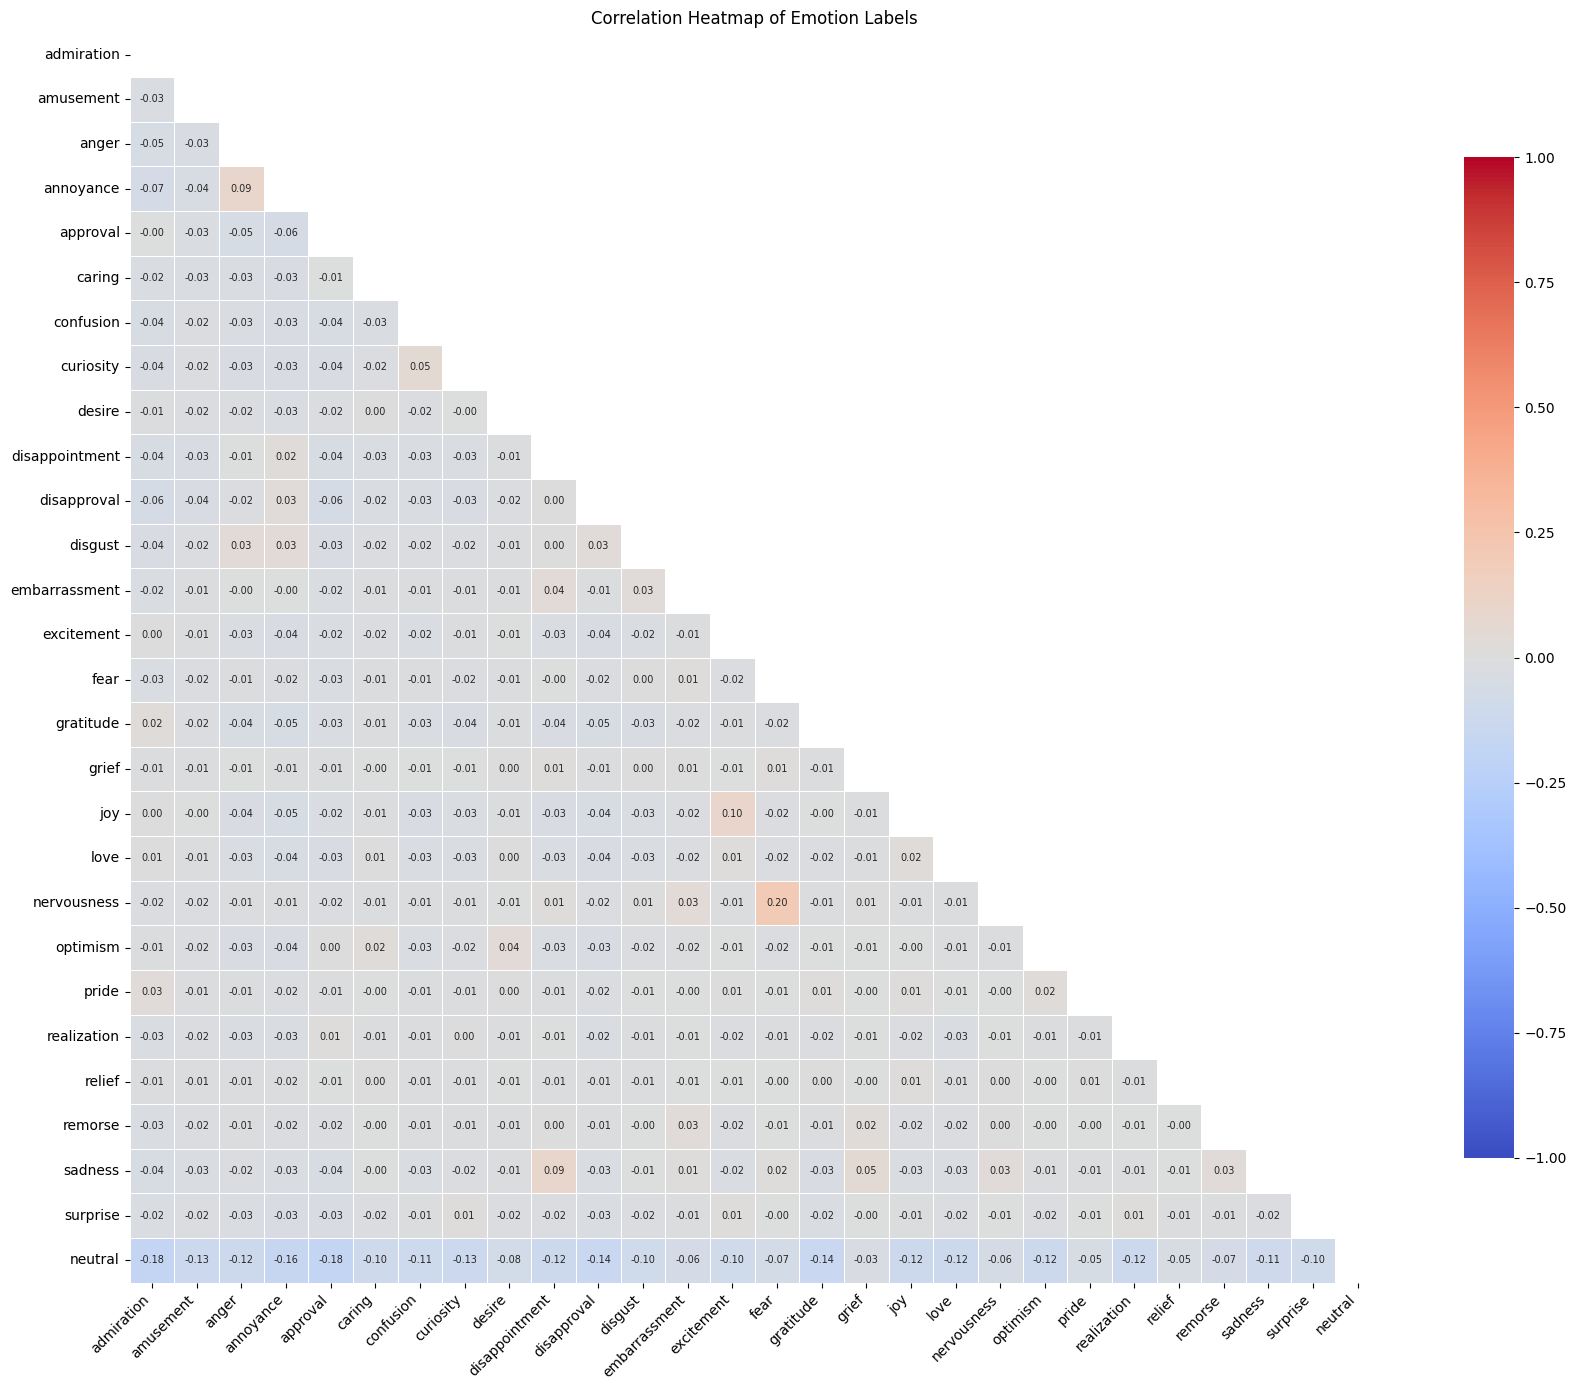

In [28]:
# heatmap for correlation matrix
corr = df[emotion_labels].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
 )
plt.title('Correlation Heatmap of Emotion Labels')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../experiments/plots/correlation_heatmap.png')
plt.show()

#### Observations
- Positive correlation between similar emotions
  - joy and excitement: 0.10
  - nervousness and fear: 0.20
  - annoyance and anger: 0.09
  - sadness and dissapointment: 0.09
  This indicates that similar or related emotions tend to apear together, which is expected in multi-label texts.
- Negative correlations with neutral:
  Most emotions have negative correlation with neutral, for example:
  - admiration and neutral has -0.18
  - annoyance and neutral has -0.16
  - gratitude and neutral has -0.14
  and there are many values around -0.10, -0.11, -0.12, -0.13
  This makes sense because texts labeled as neutral generally do not express other emotions, so they rarely co-occur.
- Overall pattern:
  - Positive correlations are generally low but meaningful, sugesting some co-occurence patterns exist.
  - Neutral tends to be mutually exclusive with other emotions.
  - Other emotion pairs mostly have week correlations, which aligns with the diversity of emotional expressions.

#### Implications
- Multi-label models should allow multiple emotions per text but account for the fact that neutral rarely co-occurs with other labels.
- Loss function like binary cross-entropy per label are appropriate since correlations are low, but we can consider class relationships.
- The correlation structure may help in feature engineering or post-processing.

# Overall Observations
- The dataset exhibits a **long-tail distribution** for both text length and emotion counts.  
- Most texts are **short and simple**, but a few complex texts exist.  
- Related emotions show **weak positive correlations**, while neutral is largely exclusive.  
- The dataset is well-suited for **multi-label classical machine learning models**, but preprocessing and careful handling of class imbalance are crucial.


# ✅ Conclusion
- The EDA reveals that this is a **multi-label, imbalanced, short-text dataset** with some outliers in both text length and emotion counts.  
- Modeling should account for:  
  1. **Multi-label outputs**  
  2. **Class imbalance** (rare vs. common emotions)  
  3. **Short, conversational text features**  
  4. **Label correlations** (weak but useful for co-occurring emotions)  

> These insights will guide preprocessing, vectorization, model selection, and evaluation strategies in the subsequent notebooks.